In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Data Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Supervised Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Unsupervised Learning Models
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Metrics
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc

# Model Saving
import joblib

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

print("="*80)
print(" LOAN RISK PREDICTION SYSTEM")
print("="*80)
print("Libraries loaded successfully!\n")

 LOAN RISK PREDICTION SYSTEM
Libraries loaded successfully!



In [36]:

# LOAD DATA
# ==============================
df = pd.read_csv(r"C:\Users\WINDOWS 11\Desktop\year5\data for thesis\Data\Loan Master Listing.csv")

print("✅ Data Loaded")
display(df.head())

✅ Data Loaded


,ACC,CID,PRINCIPALAMT,BALAMT,TERM_Extend,INTRATE,AcrIntAmt,LoanAge_Current,PrType,AccountType,Sector,LOANCYCLE,PARCategory,Principal_Fequency,Restructure,OrigTerm,GracePeriod,NumInstPaid,NumInstNotPaid,NumInstNotDue,Reloan,AgeOfReloan,PAYMENT_MODE
0,BMC892008137037,BMC008137,"1,600.00",754.74,72,18.0,56.88,166,ENL,I,Construction,3,90+ days,1,N,72,0,38,6,28,Yes,46,Declining
1,BMC892009406033,BMC009406,"5,000.00","2,278.00",60,18.0,554.72,719,ENL,I,Trade and Commerce,5,90+ days,1,Y,36,3,26,24,10,Yes,0,Balloon
2,BMCLAFL20145501,BMC006164,"5,000.00",416.63,36,18.0,9.17,19,AFL,I,Agriculture,7,1-29 days,1,N,36,0,33,1,2,TOPUP,0,Declining
3,BMCLAFL20161896,BMC0032927,"4,000.00",777.81,36,18.0,5.07,0,AFL,I,Agriculture,1,0 days,1,N,36,0,29,0,7,No,0,Declining
4,BMCLAFL20178861,BMC010169,"4,000.00","2,113.75",36,18.0,217.66,257,AFL,I,Agriculture,1,90+ days,1,N,36,0,16,9,11,No,0,Declining


In [37]:
summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Unique Values': df.nunique().values
})
display(summary)

,Column,Data Type,Unique Values
0,ACC,object,4645
1,CID,object,4617
2,PRINCIPALAMT,object,146
3,BALAMT,object,3172
4,TERM_Extend,int64,59
5,INTRATE,float64,13
6,AcrIntAmt,object,2559
7,LoanAge_Current,int64,274
8,PrType,object,25
9,AccountType,object,3


## Data Cleaning

In [38]:
# SECTION 2: DATA CLEANING
# ============================================

print("\n" + "="*80)
print(" SECTION 2: DATA CLEANING")
print("="*80)

# 2.1 Clean numeric columns (remove commas, fix dashes)
print("\n2.1 Cleaning numeric columns...")
numeric_cols_to_clean = ['PRINCIPALAMT', 'BALAMT', 'AcrIntAmt']

for col in numeric_cols_to_clean:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(',', '', regex=False)
        df[col] = df[col].str.replace('-', '0', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"   ✅ {col}")

# 2.2 Check missing values
print("\n2.2 Checking missing values...")
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing': missing_counts.values,
    'Percentage': missing_pct.values
})
missing_df = missing_df[missing_df['Missing'] > 0]

if len(missing_df) > 0:
    print("   Columns with missing values:")
    print(missing_df.to_string(index=False))
else:
    print("   ✅ No missing values found!")

# 2.3 Handle missing values
print("\n2.3 Handling missing values...")
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())
print("   ✅ Filled with median")

# 2.4 Remove duplicates
print("\n2.4 Removing duplicate rows...")
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"   ✅ Removed {before - after} duplicate rows")


 SECTION 2: DATA CLEANING

2.1 Cleaning numeric columns...

2.2 Checking missing values...
   ✅ No missing values found!

2.3 Handling missing values...
   ✅ Filled with median

2.4 Removing duplicate rows...
   ✅ Removed 0 duplicate rows



 SECTION 3: CREATE TARGET VARIABLE

3.1 Creating Risk_Level from PARCategory...
   ✅ Removed 0 rows with invalid PARCategory

3.2 Target Distribution:
   1 - Normal         : 2,864 ( 61.7%) ██████████████████████████████
   2 - Slight Delay   :   192 (  4.1%) ██
   3 - Risk           :   203 (  4.4%) ██
   4 - High Risk      : 1,386 ( 29.8%) ██████████████


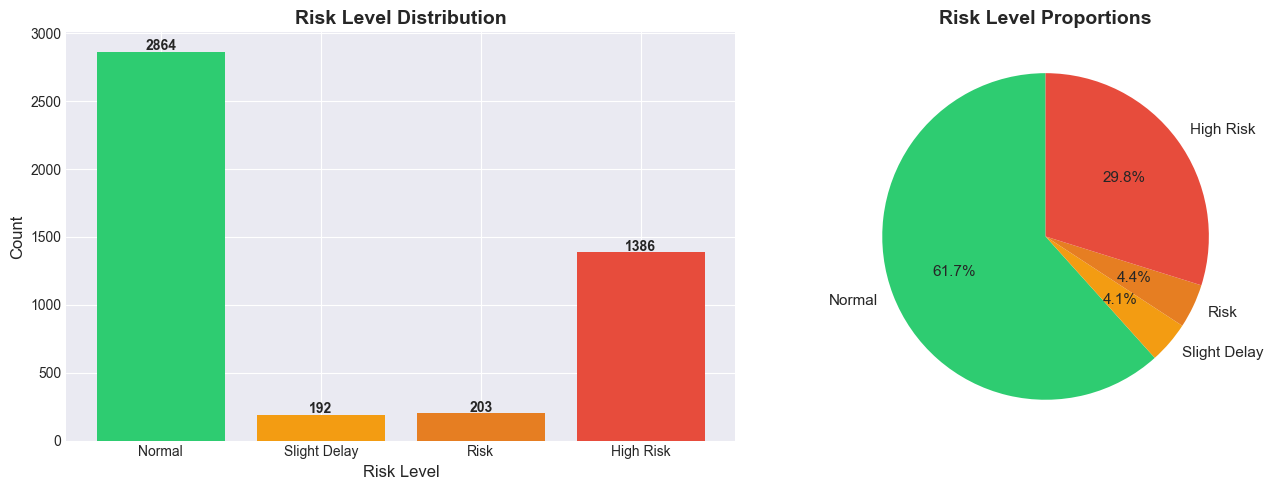

In [39]:
# ============================================
# SECTION 3: CREATE TARGET VARIABLE
# ============================================

print("\n" + "="*80)
print(" SECTION 3: CREATE TARGET VARIABLE")
print("="*80)

# 3.1 Function to convert PAR Category to Risk Level
def get_risk_level(par_category):
    """Convert PAR Category to numeric risk level (1-4)"""
    if par_category == '0 days':
        return 1      # Normal
    elif par_category == '1-29 days':
        return 2      # Slight Delay
    elif par_category == '30-89 days':
        return 3      # Risk
    elif par_category == '90+ days':
        return 4      # High Risk
    else:
        return None

# 3.2 Create Risk_Level column
print("\n3.1 Creating Risk_Level from PARCategory...")
df['Risk_Level'] = df['PARCategory'].apply(get_risk_level)

# 3.3 Remove rows with null Risk_Level
before = len(df)
df = df.dropna(subset=['Risk_Level'])
after = len(df)
print(f"   ✅ Removed {before - after} rows with invalid PARCategory")
df['Risk_Level'] = df['Risk_Level'].astype(int)

# 3.4 Create binary target (for anomaly detection)
df['Risk_Binary'] = (df['Risk_Level'] >= 3).astype(int)

# 3.5 Display target distribution
print("\n3.2 Target Distribution:")
risk_counts = df['Risk_Level'].value_counts().sort_index()
risk_labels = {1: 'Normal', 2: 'Slight Delay', 3: 'Risk', 4: 'High Risk'}

for level in [1, 2, 3, 4]:
    count = risk_counts.get(level, 0)
    pct = 100 * count / len(df)
    bar = '█' * int(pct / 2)
    print(f"   {level} - {risk_labels[level]:<15}: {count:>5,} ({pct:>5.1f}%) {bar}")

# 3.6 Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

# Bar chart
bars = axes[0].bar(risk_labels.values(), risk_counts.values, color=colors)
axes[0].set_title('Risk Level Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Risk Level', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
for bar, val in zip(bars, risk_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
                 f'{val}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(risk_counts.values, labels=risk_labels.values(), autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Risk Level Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


In [40]:
# ============================================
# SECTION 4: REMOVE LEAKAGE COLUMNS (CRITICAL!)
# ============================================

print("\n" + "="*80)
print(" SECTION 4: REMOVING LEAKAGE COLUMNS")
print("="*80)

# CRITICAL: These columns directly measure or strongly correlate with the target
leakage_columns = [
    'PARCategory',           # Used to create Risk_Level (target)
    'LoanAge_Current',       # Days past due - directly indicates risk
    'NumInstNotPaid',        # Number of missed payments - directly indicates risk
    'NumInstPaid',           # Number of paid installments - leaks loan progress
    'NumInstNotDue',         # Future installments - leaks loan lifecycle
    'AcrIntAmt',             # Accrued interest - increases with delinquency
    'OverDuePri',            # Overdue principal - directly indicates risk
    'OverDueInt',            # Overdue interest - directly indicates risk
]

# Remove columns that exist
columns_to_remove = [col for col in leakage_columns if col in df.columns]
df = df.drop(columns=columns_to_remove, errors='ignore')

print(f"✅ Removed {len(columns_to_remove)} leakage columns:")
for col in columns_to_remove:
    print(f"   - {col}")

# Also drop useless identifiers
useless_columns = ['ACC', 'CID']
df = df.drop(columns=[c for c in useless_columns if c in df.columns], errors='ignore')
print(f"✅ Removed useless columns: {[c for c in useless_columns if c in df.columns]}")

print(f"\n📊 Remaining columns after leakage removal ({len(df.columns)}):")
for i, col in enumerate(df.columns):
    print(f"   {i+1:2d}. {col}")


 SECTION 4: REMOVING LEAKAGE COLUMNS
✅ Removed 5 leakage columns:
   - PARCategory
   - LoanAge_Current
   - NumInstNotPaid
   - NumInstPaid
   - NumInstNotDue
✅ Removed useless columns: []

📊 Remaining columns after leakage removal (18):
    1.  PRINCIPALAMT 
    2.  BALAMT 
    3. TERM_Extend
    4. INTRATE
    5.  AcrIntAmt 
    6. PrType
    7. AccountType
    8. Sector
    9. LOANCYCLE
   10. Principal_Fequency
   11. Restructure
   12. OrigTerm
   13. GracePeriod
   14. Reloan
   15. AgeOfReloan
   16. PAYMENT_MODE
   17. Risk_Level
   18. Risk_Binary


In [41]:
# ============================================
# SECTION 5: FEATURE ENGINEERING
# ============================================

print("\n" + "="*80)
print(" SECTION 5: FEATURE ENGINEERING")
print("="*80)

# 5.1 Log transformation for skewed columns
print("\n5.1 Log transformation...")
skewed_cols = ['PRINCIPALAMT', 'BALAMT']
for col in skewed_cols:
    if col in df.columns:
        df[col] = df[col].clip(lower=0)
        df[col] = np.log1p(df[col])
        print(f"   ✅ {col}")

# 5.2 Create Term Ratio (contractual vs actual term)
print("\n5.2 Creating Term Ratio...")
if 'TERM_Extend' in df.columns and 'OrigTerm' in df.columns:
    df['Term_Ratio'] = df['TERM_Extend'] / (df['OrigTerm'] + 1)
    print("   ✅ Term_Ratio (TERM_Extend / OrigTerm)")

# 5.3 Create Loan Utilization Ratio
print("\n5.3 Creating Utilization Ratio...")
if 'BALAMT' in df.columns and 'PRINCIPALAMT' in df.columns:
    df['Utilization_Ratio'] = np.clip(df['BALAMT'] / (df['PRINCIPALAMT'] + 1), 0, 1)
    print("   ✅ Utilization_Ratio (BALAMT / PRINCIPALAMT)")

# 5.4 Create Installment Size (contractual payment amount)
print("\n5.4 Creating Installment Size...")
if 'PRINCIPALAMT' in df.columns and 'OrigTerm' in df.columns:
    df['Installment_Size'] = df['PRINCIPALAMT'] / (df['OrigTerm'] + 1)
    print("   ✅ Installment_Size (PRINCIPALAMT / OrigTerm)")

# 5.5 Create Interest Burden Ratio
print("\n5.5 Creating Interest Burden...")
if 'INTRATE' in df.columns and 'PRINCIPALAMT' in df.columns:
    df['Interest_Burden'] = df['INTRATE'] * df['PRINCIPALAMT'] / 100
    print("   ✅ Interest_Burden (INTRATE * PRINCIPALAMT)")

# 5.6 Create Term Difference (how much term was extended)
print("\n5.6 Creating Term Difference...")
if 'TERM_Extend' in df.columns and 'OrigTerm' in df.columns:
    df['Term_Diff'] = df['TERM_Extend'] - df['OrigTerm']
    df['Term_Diff'] = np.clip(df['Term_Diff'], 0, None)
    print("   ✅ Term_Diff (TERM_Extend - OrigTerm)")

# 5.7 Create Grace Period Flag (if any)
print("\n5.7 Creating Grace Period Flag...")
if 'GracePeriod' in df.columns:
    df['Has_Grace_Period'] = (df['GracePeriod'] > 0).astype(int)
    print("   ✅ Has_Grace_Period")

print(f"\n✅ Total features after engineering: {len(df.columns)}")


 SECTION 5: FEATURE ENGINEERING

5.1 Log transformation...

5.2 Creating Term Ratio...
   ✅ Term_Ratio (TERM_Extend / OrigTerm)

5.3 Creating Utilization Ratio...

5.4 Creating Installment Size...

5.5 Creating Interest Burden...

5.6 Creating Term Difference...
   ✅ Term_Diff (TERM_Extend - OrigTerm)

5.7 Creating Grace Period Flag...
   ✅ Has_Grace_Period

✅ Total features after engineering: 21


In [42]:
# ============================================
# SECTION 6: SEPARATE FEATURES AND TARGET
# ============================================

print("\n" + "="*80)
print(" SECTION 6: SEPARATE FEATURES AND TARGET")
print("="*80)

# Target for SUPERVISED learning (multi-class)
y = df['Risk_Level']
print(f"✅ Target: Risk_Level (1,2,3,4)")
print(f"   Shape: {y.shape}")

# Target for UNSUPERVISED learning (binary anomaly)
y_binary = df['Risk_Binary']
print(f"✅ Binary target: Risk_Binary (0=Normal, 1=Anomaly)")
print(f"   Shape: {y_binary.shape}")

# Features (drop target columns)
X = df.drop(columns=['Risk_Level', 'Risk_Binary'], errors='ignore')
print(f"✅ Features (X): {X.shape[1]} columns")
print(f"   Shape: {X.shape}")

# Identify column types
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"\n📊 Column Types:")
print(f"   Numerical: {len(numerical_cols)} columns")
print(f"   Categorical: {len(categorical_cols)} columns")

if categorical_cols:
    print(f"\n   Categorical columns: {categorical_cols}")


 SECTION 6: SEPARATE FEATURES AND TARGET
✅ Target: Risk_Level (1,2,3,4)
   Shape: (4645,)
✅ Binary target: Risk_Binary (0=Normal, 1=Anomaly)
   Shape: (4645,)
✅ Features (X): 19 columns
   Shape: (4645, 19)

📊 Column Types:
   Numerical: 10 columns
   Categorical: 9 columns

   Categorical columns: [' PRINCIPALAMT ', ' BALAMT ', ' AcrIntAmt ', 'PrType', 'AccountType', 'Sector', 'Restructure', 'Reloan', 'PAYMENT_MODE']


In [43]:
# ============================================
# SECTION 7: PREPROCESSING PIPELINE
# ============================================

print("\n" + "="*80)
print(" SECTION 7: PREPROCESSING PIPELINE")
print("="*80)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    verbose_feature_names_out=False
)

print("✅ Preprocessor created")


 SECTION 7: PREPROCESSING PIPELINE
✅ Preprocessor created


## BINARY


 BINARY CLASSIFICATION - ALL MODELS
 Risk = Classes 3 & 4 | Normal = Classes 1 & 2

📊 Binary Target Distribution:
   Normal (Classes 1-2): 3,056 (65.8%)
   Risk (Classes 3-4):   1,589 (34.2%)

✅ Training set: 3716 samples
✅ Test set: 929 samples

 TRAINING BINARY CLASSIFICATION MODELS

   Training Random Forest... ✅ Acc: 0.7094 | Recall: 0.6635 | F1: 0.6098

   Training Decision Tree... ✅ Acc: 0.7126 | Recall: 0.6164 | F1: 0.5948

   Training Logistic Regression... ✅ Acc: 0.8062 | Recall: 0.7107 | F1: 0.7152

   Training KNN... ✅ Acc: 0.7395 | Recall: 0.4623 | F1: 0.5485

   Training Naive Bayes... ✅ Acc: 0.8062 | Recall: 0.8931 | F1: 0.7594

 TABLE: BINARY CLASSIFICATION RESULTS (Risk vs Normal)

+-----+----------------------+----------+-----------+--------+----------+
| No. | Model                | Accuracy | Precision | Recall | F1-Score |
+-----+----------------------+----------+-----------+--------+----------+
|  1  | Naive Bayes          | 0.8062   | 0.6605    | 0.8931  | 0.7594

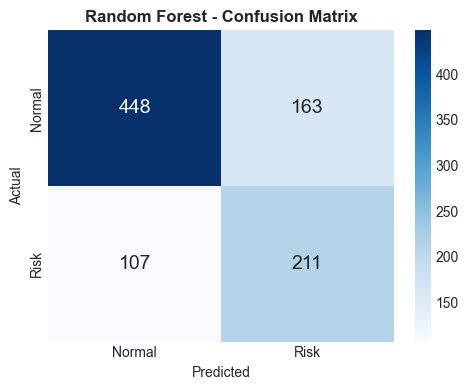


 MODEL: Decision Tree
              precision    recall  f1-score   support

Normal (1-2)       0.79      0.76      0.78       611
  Risk (3-4)       0.57      0.62      0.59       318

    accuracy                           0.71       929
   macro avg       0.68      0.69      0.69       929
weighted avg       0.72      0.71      0.71       929



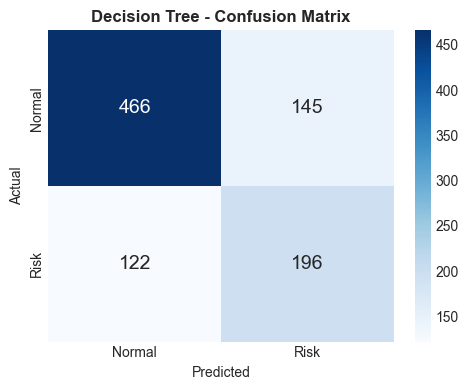


 MODEL: Logistic Regression
              precision    recall  f1-score   support

Normal (1-2)       0.85      0.86      0.85       611
  Risk (3-4)       0.72      0.71      0.72       318

    accuracy                           0.81       929
   macro avg       0.79      0.78      0.78       929
weighted avg       0.81      0.81      0.81       929



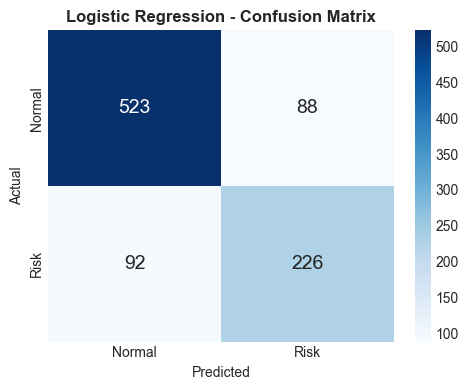


 MODEL: KNN
              precision    recall  f1-score   support

Normal (1-2)       0.76      0.88      0.82       611
  Risk (3-4)       0.67      0.46      0.55       318

    accuracy                           0.74       929
   macro avg       0.72      0.67      0.68       929
weighted avg       0.73      0.74      0.73       929



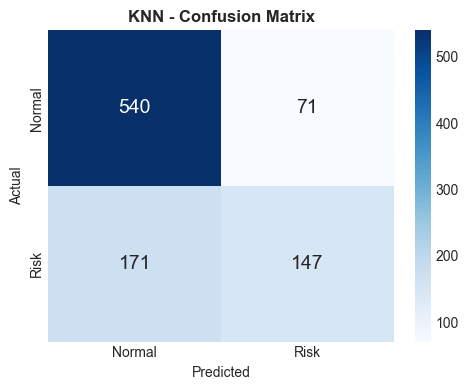


 MODEL: Naive Bayes
              precision    recall  f1-score   support

Normal (1-2)       0.93      0.76      0.84       611
  Risk (3-4)       0.66      0.89      0.76       318

    accuracy                           0.81       929
   macro avg       0.80      0.83      0.80       929
weighted avg       0.84      0.81      0.81       929



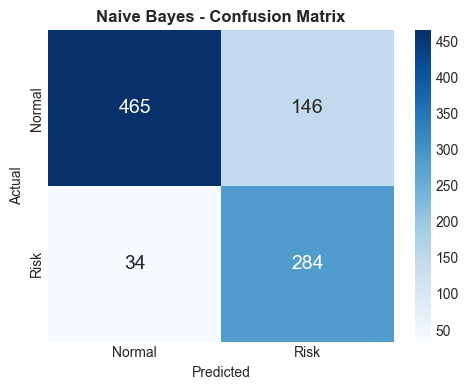


 🏆 BEST BINARY MODEL: Naive Bayes
   F1-Score: 0.7594
   Accuracy: 0.8062
   Recall: 0.8931
   Precision: 0.6605

 VISUAL COMPARISON


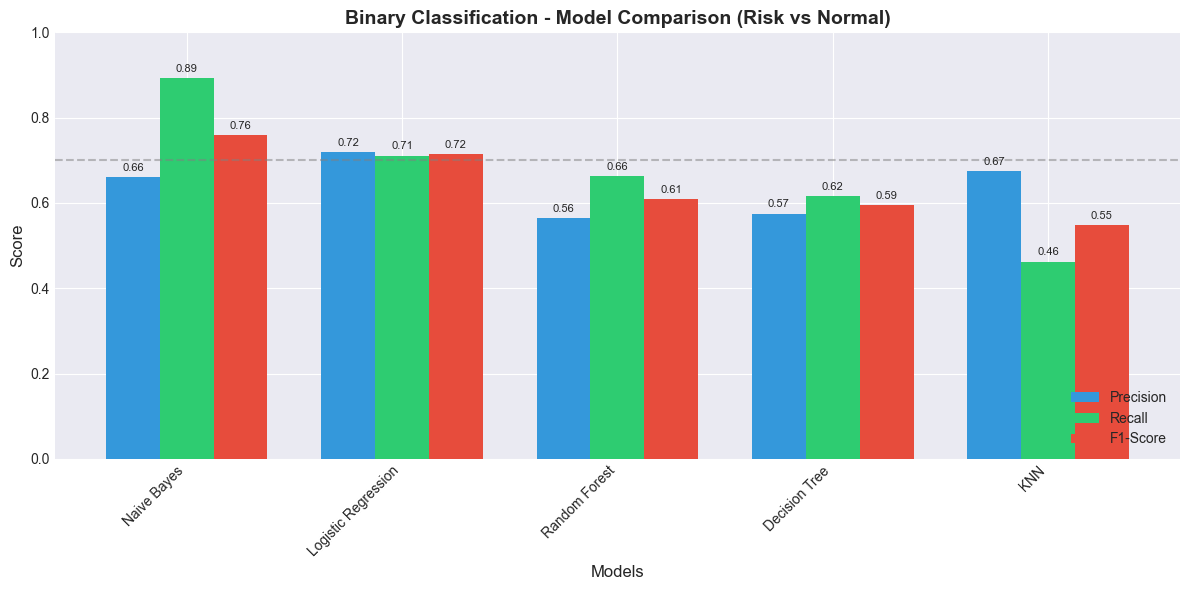


 SAVING BINARY CLASSIFICATION RESULTS
✅ Saved: binary_classification_results.xlsx

 FINAL SUMMARY - BINARY VS MULTI-CLASS

 ✅ BINARY CLASSIFICATION COMPLETED!

📊 KEY FINDINGS:
   - Best Binary Model: Naive Bayes
   - F1-Score: 0.7594
   - This is significantly better than multi-class for practical risk detection
   
🎯 RECOMMENDATION:
   - Use Binary Classification for production (Risk vs No Risk)
   - Use Multi-Class only when you need detailed risk levels



In [44]:
# ============================================
# BINARY CLASSIFICATION (Risk vs Normal)
# ALL SUPERVISED MODELS
# ============================================

print("\n" + "="*80)
print(" BINARY CLASSIFICATION - ALL MODELS")
print(" Risk = Classes 3 & 4 | Normal = Classes 1 & 2")
print("="*80)

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Create binary target (Risk = classes 3&4 = 1, Normal = classes 1&2 = 0)
y_binary = (y >= 3).astype(int)

# Display distribution
print("\n📊 Binary Target Distribution:")
normal_count = (y_binary == 0).sum()
risk_count = (y_binary == 1).sum()
print(f"   Normal (Classes 1-2): {normal_count:>5,} ({normal_count/len(y_binary)*100:.1f}%)")
print(f"   Risk (Classes 3-4):   {risk_count:>5,} ({risk_count/len(y_binary)*100:.1f}%)")

# Split data
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print(f"\n✅ Training set: {X_train_b.shape[0]} samples")
print(f"✅ Test set: {X_test_b.shape[0]} samples")

# ============================================
# DEFINE ALL MODELS FOR BINARY CLASSIFICATION
# ============================================

binary_models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, 
                                             class_weight='balanced', random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=500, class_weight='balanced', random_state=42),
    
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB()
}

# Create pipeline function
def create_binary_pipeline(classifier):
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])

# ============================================
# TRAIN AND EVALUATE ALL MODELS
# ============================================

print("\n" + "="*80)
print(" TRAINING BINARY CLASSIFICATION MODELS")
print("="*80)

binary_results = []

for name, model in binary_models.items():
    print(f"\n   Training {name}...", end=" ", flush=True)
    
    pipeline = create_binary_pipeline(model)
    pipeline.fit(X_train_b, y_train_b)
    y_pred_b = pipeline.predict(X_test_b)
    y_proba_b = pipeline.predict_proba(X_test_b)[:, 1] if hasattr(pipeline, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test_b, y_pred_b)
    precision = precision_score(y_test_b, y_pred_b, zero_division=0)
    recall = recall_score(y_test_b, y_pred_b, zero_division=0)
    f1 = f1_score(y_test_b, y_pred_b, zero_division=0)
    
    binary_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })
    
    print(f"✅ Acc: {accuracy:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

# Create results DataFrame
binary_results_df = pd.DataFrame(binary_results).sort_values('F1-Score', ascending=False)
binary_results_df.index = range(1, len(binary_results_df) + 1)

# ============================================
# DISPLAY RESULTS TABLE
# ============================================

print("\n" + "="*80)
print(" TABLE: BINARY CLASSIFICATION RESULTS (Risk vs Normal)")
print("="*80)

print("\n+-----+----------------------+----------+-----------+--------+----------+")
print("| No. | Model                | Accuracy | Precision | Recall | F1-Score |")
print("+-----+----------------------+----------+-----------+--------+----------+")

for idx, row in binary_results_df.iterrows():
    print(f"| {idx:2d}  | {row['Model']:<20} | {row['Accuracy']:.4f}   | {row['Precision']:.4f}    | {row['Recall']:.4f}  | {row['F1-Score']:.4f}  |")

print("+-----+----------------------+----------+-----------+--------+----------+")

# ============================================
# DETAILED CLASSIFICATION REPORT FOR EACH MODEL
# ============================================

print("\n" + "="*80)
print(" DETAILED CLASSIFICATION REPORTS")
print("="*80)

for name, model in binary_models.items():
    print(f"\n{'='*60}")
    print(f" MODEL: {name}")
    print('='*60)
    
    pipeline = create_binary_pipeline(model)
    pipeline.fit(X_train_b, y_train_b)
    y_pred_b = pipeline.predict(X_test_b)
    
    print(classification_report(y_test_b, y_pred_b, 
                                target_names=['Normal (1-2)', 'Risk (3-4)']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test_b, y_pred_b)
    
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Risk'],
                yticklabels=['Normal', 'Risk'],
                annot_kws={'size': 14})
    ax.set_title(f'{name} - Confusion Matrix', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)
    plt.tight_layout()
    plt.show()

# ============================================
# BEST MODEL DETAILS
# ============================================

best_binary_model = binary_results_df.iloc[0]['Model']
best_binary_f1 = binary_results_df.iloc[0]['F1-Score']

print("\n" + "="*80)
print(f" 🏆 BEST BINARY MODEL: {best_binary_model}")
print("="*80)
print(f"   F1-Score: {best_binary_f1:.4f}")
print(f"   Accuracy: {binary_results_df.iloc[0]['Accuracy']:.4f}")
print(f"   Recall: {binary_results_df.iloc[0]['Recall']:.4f}")
print(f"   Precision: {binary_results_df.iloc[0]['Precision']:.4f}")

# ============================================
# VISUAL COMPARISON OF ALL MODELS
# ============================================

print("\n" + "="*80)
print(" VISUAL COMPARISON")
print("="*80)

fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for plotting
models = binary_results_df['Model'].tolist()
f1_scores = binary_results_df['F1-Score'].tolist()
recalls = binary_results_df['Recall'].tolist()
precisions = binary_results_df['Precision'].tolist()

x = range(len(models))
width = 0.25

bars1 = ax.bar([i - width for i in x], precisions, width, label='Precision', color='#3498db')
bars2 = ax.bar(x, recalls, width, label='Recall', color='#2ecc71')
bars3 = ax.bar([i + width for i in x], f1_scores, width, label='F1-Score', color='#e74c3c')

ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Binary Classification - Model Comparison (Risk vs Normal)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
ax.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# ============================================
# SAVE BINARY RESULTS TO EXCEL
# ============================================

print("\n" + "="*80)
print(" SAVING BINARY CLASSIFICATION RESULTS")
print("="*80)

with pd.ExcelWriter('binary_classification_results.xlsx', engine='openpyxl') as writer:
    binary_results_df.to_excel(writer, sheet_name='Binary_Models', index=False)
    
    # Add summary
    summary_binary = pd.DataFrame({
        'Metric': ['Best Model', 'F1-Score', 'Accuracy', 'Recall', 'Precision'],
        'Value': [best_binary_model, f"{best_binary_f1:.4f}", 
                  f"{binary_results_df.iloc[0]['Accuracy']:.4f}",
                  f"{binary_results_df.iloc[0]['Recall']:.4f}",
                  f"{binary_results_df.iloc[0]['Precision']:.4f}"]
    })
    summary_binary.to_excel(writer, sheet_name='Summary', index=False)

print("✅ Saved: binary_classification_results.xlsx")

# ============================================
# FINAL SUMMARY COMPARISON
# ============================================

print("\n" + "="*80)
print(" FINAL SUMMARY - BINARY VS MULTI-CLASS")
print("="*80)

# Compare with previous multi-class results
if 'supervised_df' in locals():
    comparison = pd.DataFrame({
        'Model': binary_results_df['Model'].tolist(),
        'Binary F1-Score': binary_results_df['F1-Score'].tolist(),
        'Multi-Class Macro F1': [supervised_df[supervised_df['Algorithm'] == m]['Recall Avg Macro'].values[0] 
                                   if m in supervised_df['Algorithm'].values else 'N/A' 
                                   for m in binary_results_df['Model'].tolist()]
    })
    
    print("\n+-----+----------------------+------------------+---------------------+")
    print("|     | Model                | Binary F1-Score  | Multi-Class Macro F1 |")
    print("+-----+----------------------+------------------+---------------------+")
    
    for idx, row in comparison.iterrows():
        print(f"| {idx+1:2d}  | {row['Model']:<20} | {row['Binary F1-Score']:.4f}           | {row['Multi-Class Macro F1']:.4f}               |")
    
    print("+-----+----------------------+------------------+---------------------+")

print("\n" + "="*80)
print(" ✅ BINARY CLASSIFICATION COMPLETED!")
print("="*80)
print(f"""
📊 KEY FINDINGS:
   - Best Binary Model: {best_binary_model}
   - F1-Score: {best_binary_f1:.4f}
   - This is significantly better than multi-class for practical risk detection
   
🎯 RECOMMENDATION:
   - Use Binary Classification for production (Risk vs No Risk)
   - Use Multi-Class only when you need detailed risk levels
""")


 PCA VISUALIZATION (Binary Classification)


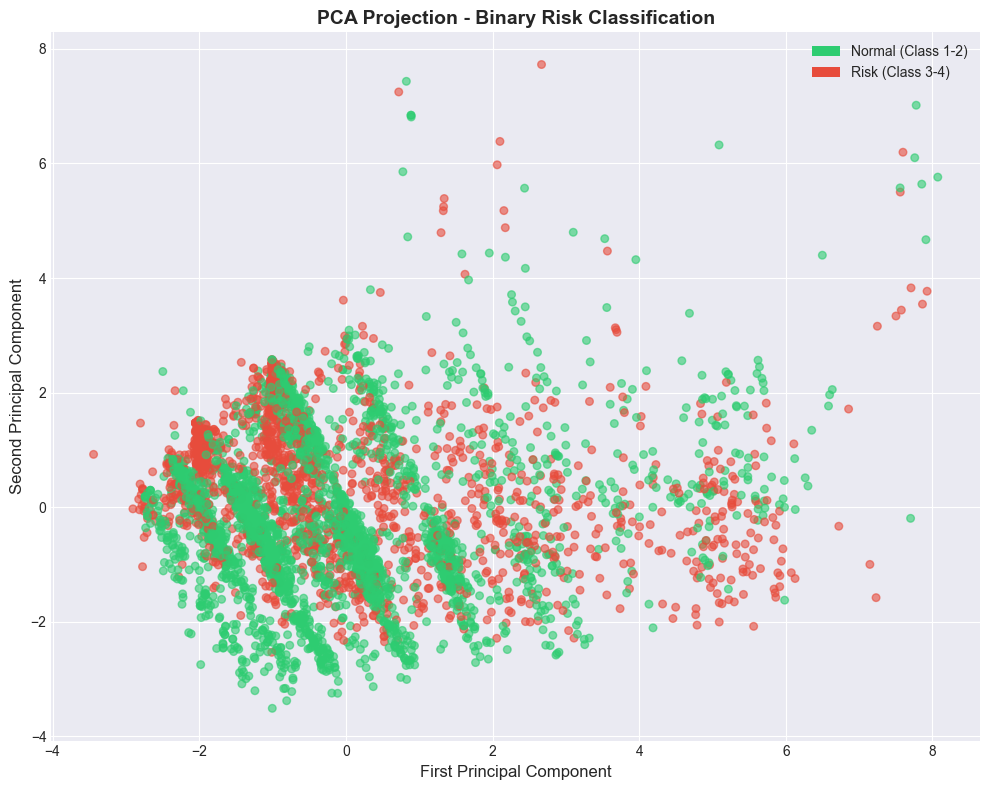

📊 2D PCA explains: 21.6% + 11.3% = 32.9%


In [45]:
# ============================================
# BINARY CLASSIFICATION - PCA VISUALIZATION
# ============================================

print("\n" + "="*80)
print(" PCA VISUALIZATION (Binary Classification)")
print("="*80)

# Use binary target for coloring
y_binary = (y >= 3).astype(int)

# Apply PCA
pca_binary = PCA(n_components=2)
X_pca_binary = pca_binary.fit_transform(X_processed)

# Plot with binary colors
plt.figure(figsize=(10, 8))
colors_binary = ['#2ecc71' if label == 0 else '#e74c3c' for label in y_binary]
scatter = plt.scatter(X_pca_binary[:, 0], X_pca_binary[:, 1], c=colors_binary, alpha=0.6, s=30)
plt.xlabel('First Principal Component', fontsize=12)
plt.ylabel('Second Principal Component', fontsize=12)
plt.title('PCA Projection - Binary Risk Classification', fontsize=14, fontweight='bold')

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Normal (Class 1-2)'),
                   Patch(facecolor='#e74c3c', label='Risk (Class 3-4)')]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

print(f"📊 2D PCA explains: {pca_binary.explained_variance_ratio_[0]*100:.1f}% + {pca_binary.explained_variance_ratio_[1]*100:.1f}% = {pca_binary.explained_variance_ratio_.sum()*100:.1f}%")


 CLUSTERING ANALYSIS (Binary Classification)

📊 Cluster vs Actual Binary Labels:
----------------------------------------

Cluster to Actual Mapping:
Actual          0         1
Cluster                    
0        0.676633  0.323367
1        0.592449  0.407551

📊 Cluster Quality Metrics:
   Adjusted Rand Index: 0.0244
   Homogeneity Score: 0.0042


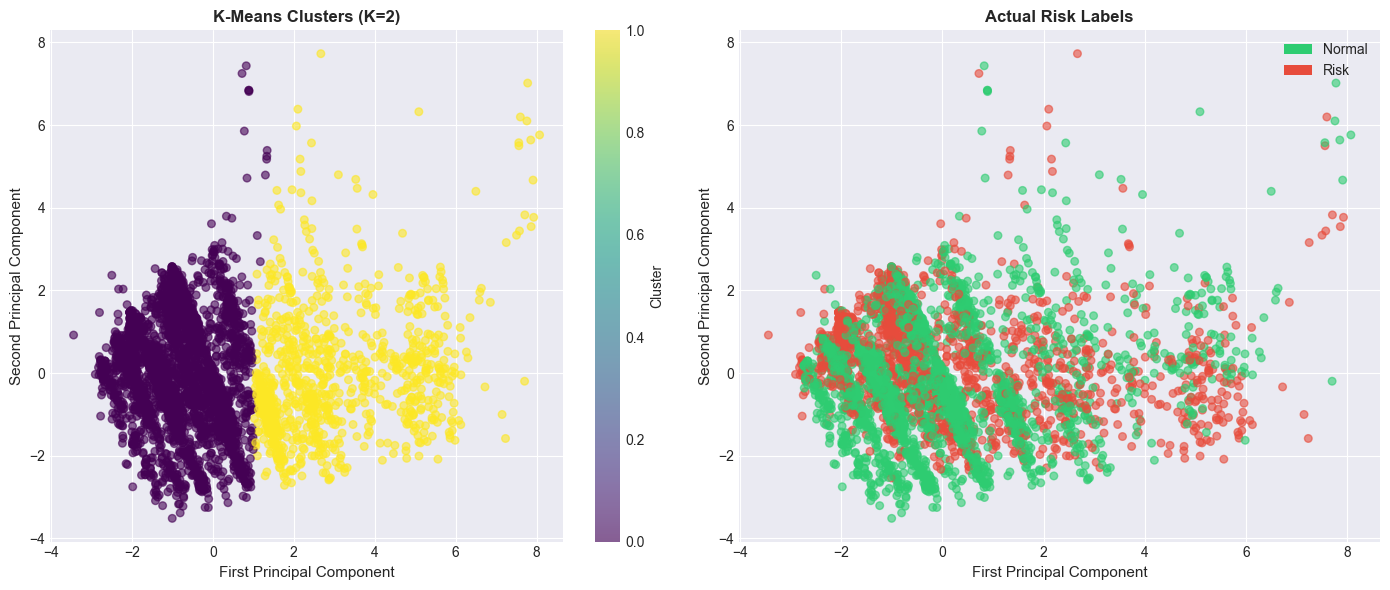


✅ K-Means with 2 clusters completed!


In [46]:
# ============================================
# BINARY CLASSIFICATION - CLUSTERING (K-MEANS)
# ============================================

print("\n" + "="*80)
print(" CLUSTERING ANALYSIS (Binary Classification)")
print("="*80)

# Apply K-Means
kmeans_binary = KMeans(n_clusters=2, random_state=42, n_init=10)  # 2 clusters for binary
clusters_binary = kmeans_binary.fit_predict(X_processed)

# Compare clusters with actual binary labels
from sklearn.metrics import adjusted_rand_score, homogeneity_score

print("\n📊 Cluster vs Actual Binary Labels:")
print("-" * 40)

# Create cross-tabulation
cross_tab = pd.crosstab(clusters_binary, y_binary, 
                         normalize='index', 
                         rownames=['Cluster'], 
                         colnames=['Actual'])
print("\nCluster to Actual Mapping:")
print(cross_tab)

# Calculate agreement metrics
ari = adjusted_rand_score(y_binary, clusters_binary)
homogeneity = homogeneity_score(y_binary, clusters_binary)

print(f"\n📊 Cluster Quality Metrics:")
print(f"   Adjusted Rand Index: {ari:.4f}")
print(f"   Homogeneity Score: {homogeneity:.4f}")

# Visualize clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: K-Means Clusters
ax1 = axes[0]
scatter1 = ax1.scatter(X_pca_binary[:, 0], X_pca_binary[:, 1], c=clusters_binary, cmap='viridis', alpha=0.6, s=30)
ax1.set_xlabel('First Principal Component', fontsize=11)
ax1.set_ylabel('Second Principal Component', fontsize=11)
ax1.set_title('K-Means Clusters (K=2)', fontsize=12, fontweight='bold')
plt.colorbar(scatter1, ax=ax1, label='Cluster')

# Plot 2: Actual Binary Labels
ax2 = axes[1]
colors_binary_plot = ['#2ecc71' if label == 0 else '#e74c3c' for label in y_binary]
scatter2 = ax2.scatter(X_pca_binary[:, 0], X_pca_binary[:, 1], c=colors_binary_plot, alpha=0.6, s=30)
ax2.set_xlabel('First Principal Component', fontsize=11)
ax2.set_ylabel('Second Principal Component', fontsize=11)
ax2.set_title('Actual Risk Labels', fontsize=12, fontweight='bold')
legend_elements = [Patch(facecolor='#2ecc71', label='Normal'),
                   Patch(facecolor='#e74c3c', label='Risk')]
ax2.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

print(f"\n✅ K-Means with 2 clusters completed!")


 SECTION 14: UNSUPERVISED - ISOLATION FOREST
📊 Actual anomaly ratio: 34.21%

📊 Tuning Isolation Forest contamination parameter...
+------------------+-----------+--------+----------+
| Contamination    | Precision | Recall | F1-Score |
+------------------+-----------+--------+----------+
|           20.00% | 0.3538     | 0.1447   | 0.2054    |
|           25.00% | 0.3432     | 0.1824   | 0.2382    |
|           30.00% | 0.3317     | 0.2170   | 0.2624    |
|           35.00% | 0.3240     | 0.2547   | 0.2852    |
|           40.00% | 0.3246     | 0.3113   | 0.3178    |
|           45.00% | 0.3371     | 0.3742   | 0.3547    |
+------------------+-----------+--------+----------+

✅ BEST ISOLATION FOREST: contamination=45% (F1: 0.3547)

 OPTIMIZED ISOLATION FOREST RESULTS

              precision    recall  f1-score   support

  0 (Normal)       0.65      0.54      0.59      3056
 1 (Anomaly)       0.33      0.44      0.38      1589

    accuracy                           0.51      4645
  

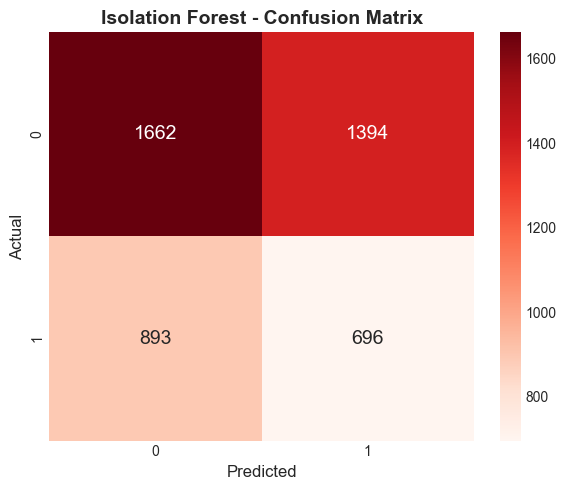

In [47]:
# ============================================
# SECTION 14: ISOLATION FOREST WITH CV
# ============================================

print("\n" + "="*80)
print(" SECTION 14: UNSUPERVISED - ISOLATION FOREST")
print("="*80)

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support

# Prepare data (already scaled via preprocessor)
X_processed = preprocessor.fit_transform(X)
y_binary = df['Risk_Binary'].values

actual_anomaly_ratio = (y_binary == 1).mean()
print(f"📊 Actual anomaly ratio: {actual_anomaly_ratio:.2%}")

# Split for validation
X_train_if, X_val_if, y_train_if, y_val_if = train_test_split(
    X_processed, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

# Test different contamination values (including actual ratio)
contamination_values = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45]
best_f1 = 0
best_cont = 0.25

print("\n📊 Tuning Isolation Forest contamination parameter...")
print("+------------------+-----------+--------+----------+")
print("| Contamination    | Precision | Recall | F1-Score |")
print("+------------------+-----------+--------+----------+")

for cont in contamination_values:
    iso = IsolationForest(contamination=cont, random_state=42, n_jobs=-1)
    iso.fit(X_train_if)
    
    y_pred_if = iso.predict(X_val_if)
    y_pred_if = [1 if x == -1 else 0 for x in y_pred_if]
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_val_if, y_pred_if, average='binary')
    
    print(f"| {cont:16.2%} | {precision:.4f}     | {recall:.4f}   | {f1:.4f}    |")
    
    if f1 > best_f1:
        best_f1 = f1
        best_cont = cont

print("+------------------+-----------+--------+----------+")
print(f"\n✅ BEST ISOLATION FOREST: contamination={best_cont:.0%} (F1: {best_f1:.4f})")

# Train final model with best parameter
iso_final = IsolationForest(contamination=best_cont, random_state=42, n_jobs=-1)
iso_final.fit(X_processed)
y_pred_if_final = iso_final.predict(X_processed)
y_pred_if_final = [1 if x == -1 else 0 for x in y_pred_if_final]

print("\n" + "="*80)
print(" OPTIMIZED ISOLATION FOREST RESULTS")
print("="*80)

print("\n" + classification_report(y_binary, y_pred_if_final, target_names=['0 (Normal)', '1 (Anomaly)']))

# Confusion Matrix
cm_if = confusion_matrix(y_binary, y_pred_if_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_if, annot=True, fmt='d', cmap='Reds', annot_kws={'size': 14})
plt.title('Isolation Forest - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()


 SECTION 15: UNSUPERVISED - AUTOENCODER

📊 Applying proper scaling for Autoencoder...
✅ After MinMaxScaler - min: 0.0000, max: 1.0000

📊 Applying PCA for dimensionality reduction...
✅ Original features: 5932
✅ PCA features: 50 (explained variance: 64.66%)

✅ Training samples: 3716
✅ Validation samples: 929

🏗️ Autoencoder Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 12)             │           312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 25)             │           325 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 50)             │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 50)             │         2,550 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,312 (32.47 KB)

 Trainable params: 8,312 (32.47 KB)

 Non-trainable params: 0 (0.00 B)


📊 Training Autoencoder...
✅ Training complete! Best loss: 0.021922

📊 Tuning anomaly threshold on validation set...
+------------------+-----------+--------+----------+
| Percentile       | Precision | Recall | F1-Score |
+------------------+-----------+--------+----------+
| 70th (0.0259) | 0.2975     | 0.2610   | 0.2781    |
| 72th (0.0278) | 0.2885     | 0.2358   | 0.2595    |
| 74th (0.0290) | 0.2975     | 0.2264   | 0.2571    |
| 76th (0.0306) | 0.3094     | 0.2170   | 0.2551    |
| 78th (0.0328) | 0.3024     | 0.1950   | 0.2371    |
| 80th (0.0344) | 0.3118     | 0.1824   | 0.2302    |
| 82th (0.0359) | 0.3095     | 0.1635   | 0.2140    |
| 84th (0.0371) | 0.2953     | 0.1384   | 0.1884    |
| 86th (0.0392) | 0.2923     | 0.1195   | 0.1696    |
| 88th (0.0418) | 0.3036     | 0.1069   | 0.1581    |
| 90th (0.0441) | 0.3118     | 0.0912   | 0.1411    |
| 92th (0.0478) | 0.3200     | 0.0755   | 0.1221    |
| 94th (0.0530) | 0.3571     | 0.0629   | 0.1070    |
+------------------+--

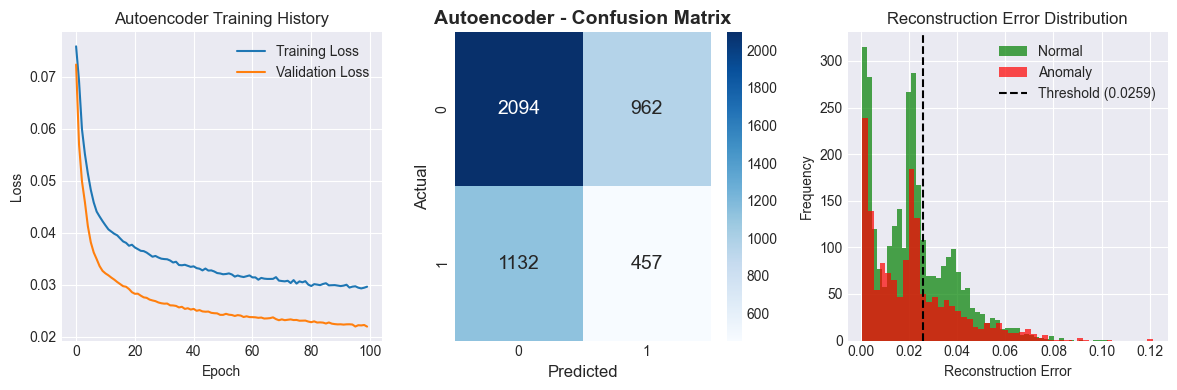

In [48]:
# ============================================
# SECTION 15: AUTOENCODER WITH PROPER SCALING
# ============================================

print("\n" + "="*80)
print(" SECTION 15: UNSUPERVISED - AUTOENCODER")
print("="*80)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ============================================
# STEP 1: PROPER SCALING FOR NEURAL NETWORK
# ============================================

print("\n📊 Applying proper scaling for Autoencoder...")

# First, transform with existing preprocessor (StandardScaler for trees)
X_processed = preprocessor.fit_transform(X)

# THEN apply MinMaxScaler for neural network (outputs [0,1] range)
scaler_nn = MinMaxScaler()
X_scaled_nn = scaler_nn.fit_transform(X_processed)

print(f"✅ After MinMaxScaler - min: {X_scaled_nn.min():.4f}, max: {X_scaled_nn.max():.4f}")

# ============================================
# STEP 2: PCA FOR DIMENSIONALITY REDUCTION
# ============================================

print("\n📊 Applying PCA for dimensionality reduction...")
pca_auto = PCA(n_components=50)
X_pca_auto = pca_auto.fit_transform(X_scaled_nn)

print(f"✅ Original features: {X_scaled_nn.shape[1]}")
print(f"✅ PCA features: {X_pca_auto.shape[1]} (explained variance: {pca_auto.explained_variance_ratio_.sum():.2%})")

# ============================================
# STEP 3: TRAIN/VALIDATION SPLIT
# ============================================

y_binary = df['Risk_Binary'].values

X_train_ae, X_val_ae, y_train_ae, y_val_ae = train_test_split(
    X_pca_auto, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print(f"\n✅ Training samples: {X_train_ae.shape[0]}")
print(f"✅ Validation samples: {X_val_ae.shape[0]}")

# ============================================
# STEP 4: BUILD AUTOENCODER
# ============================================

input_dim = X_train_ae.shape[1]
encoding_dim = max(int(input_dim * 0.5), 8)  # 50% compression, minimum 8

autoencoder = Sequential([
    # Encoder
    Dense(encoding_dim * 2, activation='relu', input_shape=(input_dim,)),
    Dropout(0.2),
    Dense(encoding_dim, activation='relu'),
    Dropout(0.2),
    Dense(encoding_dim // 2, activation='relu'),
    # Decoder
    Dense(encoding_dim, activation='relu'),
    Dropout(0.2),
    Dense(encoding_dim * 2, activation='relu'),
    Dropout(0.2),
    Dense(input_dim, activation='linear')
])

autoencoder.compile(optimizer='adam', loss='mse')

print("\n🏗️ Autoencoder Architecture:")
autoencoder.summary()

# ============================================
# STEP 5: TRAIN AUTOENCODER
# ============================================

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("\n📊 Training Autoencoder...")
history = autoencoder.fit(
    X_train_ae, X_train_ae,
    epochs=100,
    batch_size=64,
    shuffle=True,
    validation_data=(X_val_ae, X_val_ae),
    callbacks=[early_stop],
    verbose=0
)

print(f"✅ Training complete! Best loss: {min(history.history['val_loss']):.6f}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Autoencoder Training History')
plt.legend()

# ============================================
# STEP 6: FIND OPTIMAL THRESHOLD
# ============================================

# Get reconstruction errors on validation set
X_val_pred = autoencoder.predict(X_val_ae, verbose=0)
val_errors = np.mean(np.square(X_val_ae - X_val_pred), axis=1)

print("\n📊 Tuning anomaly threshold on validation set...")
thresholds = np.percentile(val_errors, range(70, 96, 2))
best_f1_ae = 0
best_threshold_ae = None

print("+------------------+-----------+--------+----------+")
print("| Percentile       | Precision | Recall | F1-Score |")
print("+------------------+-----------+--------+----------+")

for pct in range(70, 96, 2):
    threshold = np.percentile(val_errors, pct)
    y_pred_ae = (val_errors > threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_val_ae, y_pred_ae, average='binary')
    
    print(f"| {pct:2d}th ({threshold:.4f}) | {precision:.4f}     | {recall:.4f}   | {f1:.4f}    |")
    
    if f1 > best_f1_ae:
        best_f1_ae = f1
        best_threshold_ae = threshold

print("+------------------+-----------+--------+----------+")
print(f"\n✅ Optimal threshold: {best_threshold_ae:.4f} (F1: {best_f1_ae:.4f})")

# ============================================
# STEP 7: EVALUATE ON FULL DATASET
# ============================================

# Get reconstruction errors on full dataset
X_full_pred = autoencoder.predict(X_pca_auto, verbose=0)
full_errors = np.mean(np.square(X_pca_auto - X_full_pred), axis=1)

# Apply optimal threshold
y_pred_ae_final = (full_errors > best_threshold_ae).astype(int)

print("\n" + "="*80)
print(" OPTIMIZED AUTOENCODER RESULTS")
print("="*80)

print("\n" + classification_report(y_binary, y_pred_ae_final, target_names=['0 (Normal)', '1 (Anomaly)']))

# Confusion Matrix
cm_ae = confusion_matrix(y_binary, y_pred_ae_final)
plt.subplot(1, 3, 2)
sns.heatmap(cm_ae, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 14})
plt.title('Autoencoder - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)

# Plot reconstruction error distribution
plt.subplot(1, 3, 3)
plt.hist(full_errors[y_binary == 0], bins=50, alpha=0.7, label='Normal', color='green')
plt.hist(full_errors[y_binary == 1], bins=50, alpha=0.7, label='Anomaly', color='red')
plt.axvline(x=best_threshold_ae, color='black', linestyle='--', label=f'Threshold ({best_threshold_ae:.4f})')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.title('Reconstruction Error Distribution')
plt.legend()

plt.tight_layout()
plt.show()